In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OrdinalEncoder,
    OneHotEncoder,
    PolynomialFeatures,
    PowerTransformer,
    RobustScaler,
    StandardScaler,
    QuantileTransformer,
)

from joblib import dump

from src.config import DADOS_LIMPOS, MODELO_FINAL
from src.auxiliares import dataframe_coeficientes
from src.graficos import (
    plot_coeficientes,
    plot_comparar_metricas_modelos,
    plot_residuos_estimador,
)
from src.models import (
    organiza_resultados,
    treinar_e_validar_modelo_regressao,
    grid_search_cv_regressor,
)

In [2]:
df = pd.read_parquet(DADOS_LIMPOS)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,median_income_cat,rooms_per_household,population_per_household,bedrooms_per_room
0,-122.230003,37.880001,41,880,129,322,126,8.3252,452600,NEAR BAY,5,6.984127,2.555556,0.146591
1,-122.220001,37.860001,21,7099,1106,2401,1138,8.3014,358500,NEAR BAY,5,6.238137,2.109842,0.155797
2,-122.260002,37.840000,42,2555,665,1206,595,2.0804,226700,NEAR BAY,2,4.294117,2.026891,0.260274
3,-122.260002,37.849998,50,1120,283,697,264,2.1250,140000,NEAR BAY,2,4.242424,2.640152,0.252679
4,-122.260002,37.840000,50,2239,455,990,419,1.9911,158700,NEAR BAY,2,5.343676,2.362768,0.203216


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17564 entries, 0 to 17563
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 17564 non-null  float32
 1   latitude                  17564 non-null  float32
 2   housing_median_age        17564 non-null  int8   
 3   total_rooms               17564 non-null  int16  
 4   total_bedrooms            17564 non-null  int16  
 5   population                17564 non-null  int16  
 6   households                17564 non-null  int16  
 7   median_income             17564 non-null  float32
 8   median_house_value        17564 non-null  int32  
 9   ocean_proximity           17564 non-null  object 
 10  median_income_cat         17564 non-null  int64  
 11  rooms_per_household       17564 non-null  float32
 12  population_per_household  17564 non-null  float32
 13  bedrooms_per_room         17564 non-null  float32
dtypes: flo

In [4]:
coluna_target = ['median_house_value']

coluna_one_hot_encoder = ['ocean_proximity']

coluna_ordinal_encoder = ['median_income_cat']

In [5]:
colunas_robust_scaler = df.columns.difference(coluna_target + coluna_one_hot_encoder + coluna_ordinal_encoder)

colunas_robust_scaler

Index(['bedrooms_per_room', 'households', 'housing_median_age', 'latitude',
       'longitude', 'median_income', 'population', 'population_per_household',
       'rooms_per_household', 'total_bedrooms', 'total_rooms'],
      dtype='object')

In [6]:
pipeline_robust = Pipeline(steps=[
    ('robust_scaler', RobustScaler()),
    ('poly', PolynomialFeatures(degree=1, include_bias=False)),
])

preprocessamento = ColumnTransformer(
    transformers=[
        ('ordinal_encoder', OrdinalEncoder(categories='auto'), coluna_ordinal_encoder),
        ('one_hot', OneHotEncoder(drop='first'), coluna_one_hot_encoder),
        ('robust_scaler_poly', pipeline_robust, colunas_robust_scaler)
    ]
)

In [7]:
X = df.drop(columns=coluna_target)
y = df[coluna_target]

In [8]:
param_grid = {
    'regressor__preprocessor__robust_scaler_poly__poly__degree': [1, 2, 3],
    'regressor__reg__alpha': [1E-2, 5E-2, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]
}

In [9]:
grid_search = grid_search_cv_regressor(
    regressor=Ridge(),
    preprocessor=preprocessamento,
    target_transformer=QuantileTransformer(output_distribution='normal'),
    param_grid=param_grid
)

grid_search

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=TransformedTargetRegressor(regressor=Pipeline(steps=[('preprocessor',
                                                                             ColumnTransformer(transformers=[('ordinal_encoder',
                                                                                                              OrdinalEncoder(),
                                                                                                              ['median_income_cat']),
                                                                                                             ('one_hot',
                                                                                                              OneHotEncoder(drop='first'),
                                                                                                              ['ocean_proximity']),
                                                                                                             ('robust_scaler_poly',
                                                                                                              Pipeline(steps=[('robust_scaler',
                                                                                                                               Ro...
                                                                             Ridge())]),
                                                  transformer=QuantileTransformer(output_distribution='normal')),
             n_jobs=-1,
             param_grid={'regressor__preprocessor__robust_scaler_poly__poly__degree': [1,
                                                                                       2,
                                                                                       3],
                         'regressor__reg__alpha': [0.01, 0.05, 0.1, 0.25, 0.5,
                                                   1.0, 2.0, 5.0, 10.0, 20.0]},
             refit='neg_root_mean_squared_error',
             scoring=['r2', 'neg_mean_absolute_error',
                      'neg_root_mean_squared_error'],
             verbose=1)

In [10]:
grid_search.fit(X, y)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=TransformedTargetRegressor(regressor=Pipeline(steps=[('preprocessor',
                                                                             ColumnTransformer(transformers=[('ordinal_encoder',
                                                                                                              OrdinalEncoder(),
                                                                                                              ['median_income_cat']),
                                                                                                             ('one_hot',
                                                                                                              OneHotEncoder(drop='first'),
                                                                                                              ['ocean_proximity']),
                                                                                                             ('robust_scaler_poly',
                                                                                                              Pipeline(steps=[('robust_scaler',
                                                                                                                               Ro...
                                                                             Ridge())]),
                                                  transformer=QuantileTransformer(output_distribution='normal')),
             n_jobs=-1,
             param_grid={'regressor__preprocessor__robust_scaler_poly__poly__degree': [1,
                                                                                       2,
                                                                                       3],
                         'regressor__reg__alpha': [0.01, 0.05, 0.1, 0.25, 0.5,
                                                   1.0, 2.0, 5.0, 10.0, 20.0]},
             refit='neg_root_mean_squared_error',
             scoring=['r2', 'neg_mean_absolute_error',
                      'neg_root_mean_squared_error'],
             verbose=1)

In [11]:
grid_search.best_params_

{'regressor__preprocessor__robust_scaler_poly__poly__degree': 3,
 'regressor__reg__alpha': 20.0}

In [12]:
grid_search.best_score_

-50460.34202978261

In [13]:
coefs = dataframe_coeficientes(
    coefs=grid_search.best_estimator_.regressor_['reg'].coef_,
    colunas=grid_search.best_estimator_.regressor_['preprocessor'].get_feature_names_out(),
)

coefs

,coeficiente
robust_scaler_poly__longitude,-0.882309
robust_scaler_poly__latitude,-0.787014
one_hot__ocean_proximity_INLAND,-0.491805
robust_scaler_poly__population_per_household,-0.330843
robust_scaler_poly__latitude^2,-0.287092
...,...
robust_scaler_poly__housing_median_age longitude^2,0.190753
robust_scaler_poly__latitude median_income population_per_household,0.216907
robust_scaler_poly__housing_median_age median_income,0.246391
robust_scaler_poly__bedrooms_per_room,0.316393


In [14]:
coefs[coefs['coeficiente'] == 0]

,coeficiente


In [15]:
coefs[coefs['coeficiente'].between(-0.2, 0.2) & (coefs['coeficiente'] != 0)]

,coeficiente
robust_scaler_poly__longitude^3,-0.197945
one_hot__ocean_proximity_NEAR BAY,-0.195247
robust_scaler_poly__longitude^2 rooms_per_household,-0.175237
robust_scaler_poly__housing_median_age median_income population_per_household,-0.170467
robust_scaler_poly__latitude^2 population,-0.170113
...,...
robust_scaler_poly__bedrooms_per_room housing_median_age total_rooms,0.170141
robust_scaler_poly__bedrooms_per_room median_income,0.175741
robust_scaler_poly__latitude^2 longitude,0.184583
robust_scaler_poly__longitude median_income population_per_household,0.185648


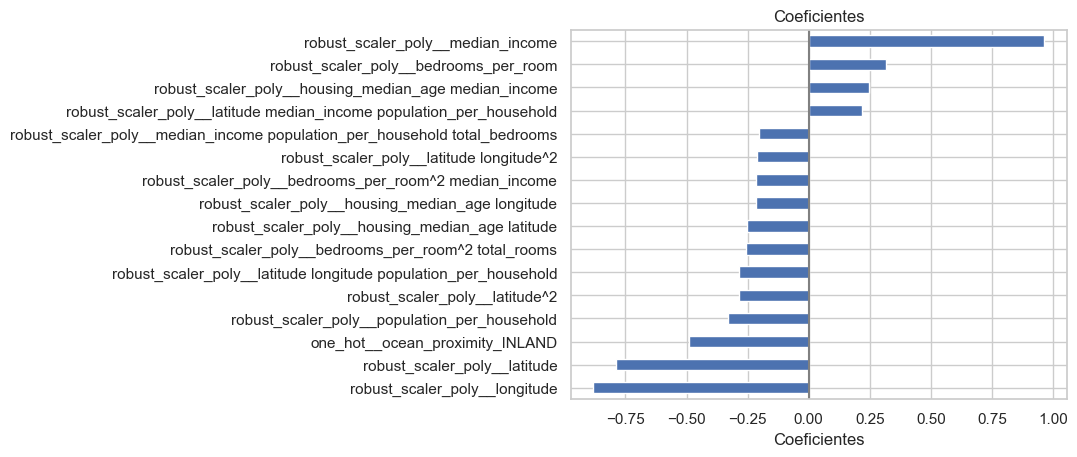

In [16]:
plot_coeficientes(coefs[~coefs['coeficiente'].between(-0.2, 0.2)])

In [17]:
regressors = {
    'DummyRegressor': {
        'preprocessor': None,
        'regressor': DummyRegressor(strategy='mean'),
        'target_transformer': None
    },

    'Ridge': {
        'preprocessor': preprocessamento,
        'regressor': LinearRegression(),
        'target_transformer': None
    },

    'Ridge_target': {
        'preprocessor': preprocessamento,
        'regressor': LinearRegression(),
        'target_transformer': QuantileTransformer(output_distribution='normal')
    },

    'Ridge_grid_search': {
        'preprocessor': grid_search.best_estimator_.regressor_['preprocessor'],
        'regressor': grid_search.best_estimator_.regressor_['reg'],
        'target_transformer': grid_search.best_estimator_.transformer_
    },
}

In [18]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_regressao(X, y, **regressor)
    for nome_modelo, regressor in regressors.items()
}

df_resultados = organiza_resultados(resultados)

df_resultados

,model,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,time_seconds
0,DummyRegressor,0.024329,0.017407,-0.000081,-77516.042766,-96239.705692,0.041737
1,DummyRegressor,0.009407,0.014806,-0.000146,-75787.787194,-95217.629397,0.024212
2,DummyRegressor,0.012053,0.014273,-0.001737,-76753.598961,-96253.253947,0.026327
3,DummyRegressor,0.002366,0.026561,-0.000101,-76837.804811,-95983.885799,0.028927
4,DummyRegressor,0.013895,0.012797,-0.000114,-76617.245449,-96182.764729,0.026692
5,Ridge,0.12893,0.034835,0.682162,-39855.690996,-54254.958188,0.163765
6,Ridge,0.088968,0.039696,0.66999,-40272.565467,-54695.230283,0.128663
7,Ridge,0.093881,0.035276,0.649247,-42178.05929,-56955.988706,0.129157
8,Ridge,0.080533,0.031953,0.669873,-40806.492497,-55146.318803,0.112487
9,Ridge,0.095776,0.026416,0.669023,-40788.496497,-55331.35106,0.122192


In [19]:
df_resultados.groupby('model').mean()

,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,time_seconds
model,,,,,,
DummyRegressor,0.01241,0.017169,-0.000436,-76702.495836,-95975.447913,0.029579
Ridge,0.097618,0.033635,0.668059,-40780.26095,-55276.769408,0.131253
Ridge_grid_search,0.520431,0.05831,0.723225,-35373.227113,-50462.558712,0.578742
Ridge_target,0.116894,0.036489,0.678472,-38671.178072,-54398.990154,0.153383


In [20]:
df_resultados.groupby('model').mean().sort_values(by='test_neg_root_mean_squared_error', ascending=False)

,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,time_seconds
model,,,,,,
Ridge_grid_search,0.520431,0.05831,0.723225,-35373.227113,-50462.558712,0.578742
Ridge_target,0.116894,0.036489,0.678472,-38671.178072,-54398.990154,0.153383
Ridge,0.097618,0.033635,0.668059,-40780.26095,-55276.769408,0.131253
DummyRegressor,0.01241,0.017169,-0.000436,-76702.495836,-95975.447913,0.029579


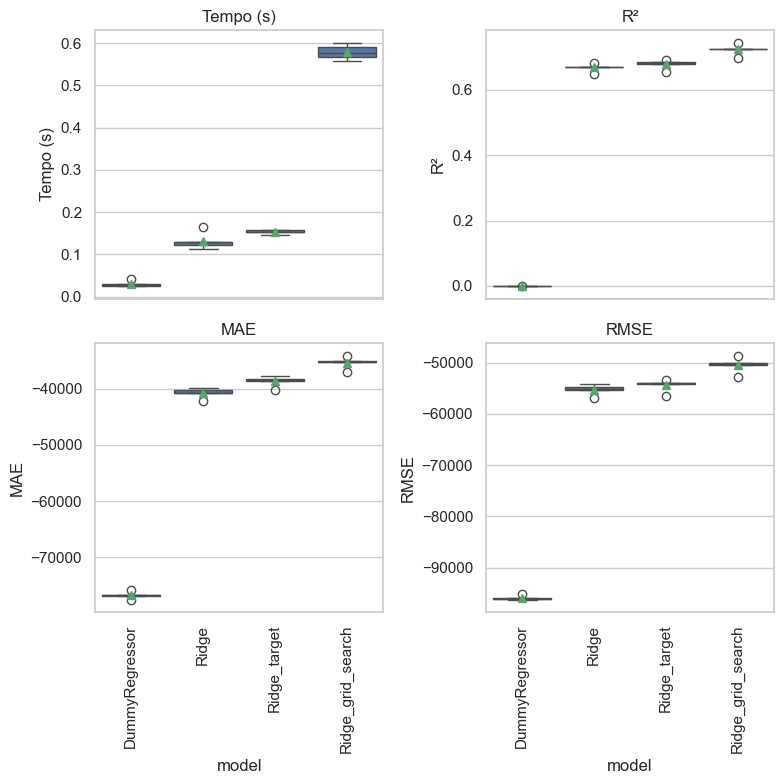

In [21]:
plot_comparar_metricas_modelos(df_resultados)

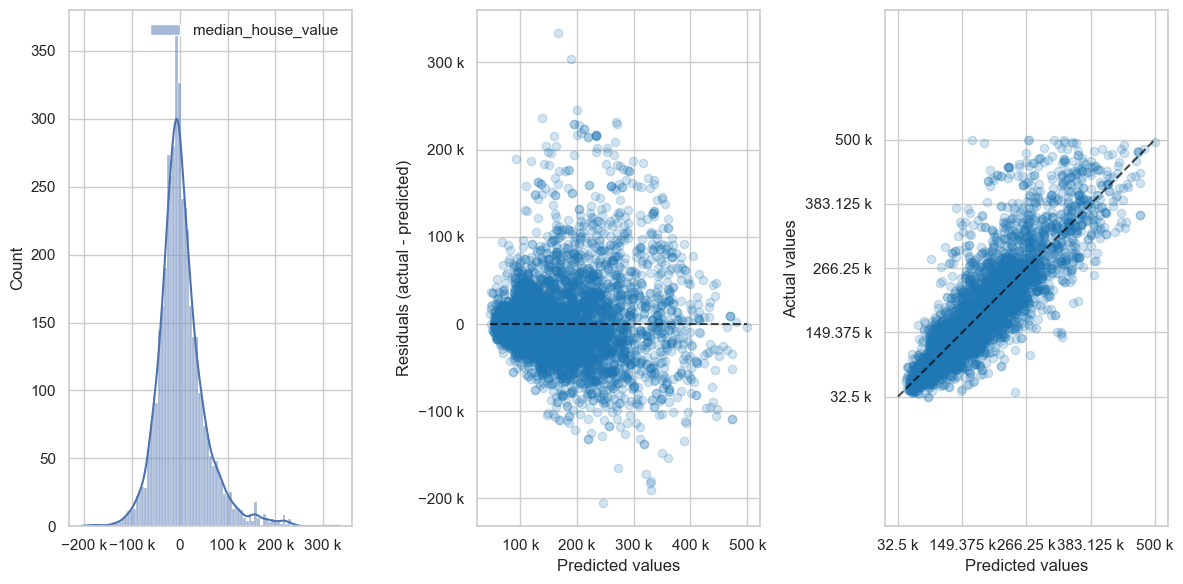

In [22]:
plot_residuos_estimador(grid_search.best_estimator_, X, y, eng_formatter=True)

https://scikit-learn.org/stable/model_persistence.html

In [23]:
dump(grid_search.best_estimator_, MODELO_FINAL)

['C:\\Users\\trc_g\\hashtag\\014_regressao_com_modelos_lineares\\05_projeto\\modelos\\ridge_pylyfeat_target_quantile.joblib']